# Evaluation of RAG Retrieval System

The notebook will evaluate:
- Document processing performance
- Retrieval quality
- Response generation
- End-to-end system performance
- Generate visualizations of the results

## Setup and imports

In [13]:
import os
import sys
import json
import logging
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from datetime import datetime

# Add src to path
src_path = str(Path.cwd().parent / 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# Import RAG4GOV components
from preprocessing import document_processor
from models.embedding_model import EmbeddingModel
from models.session_model import SessionManager
from retrieval.vector_store import VectorStore
from retrieval.rag_connector import RAGConnector
from generation.generator import Generator

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

## Document Processing Evaluation

In [14]:
def evaluate_document_processing(pdf_folder="../public"):
    """Evaluate document processing performance."""
    results = {
        'total_pdfs': 0,
        'successful_extractions': 0,
        'ocr_fallbacks': 0,
        'failed_extractions': 0,
        'processing_times': [],
        'extracted_tables': 0,
        'extracted_text_chunks': 0
    }
    
    start_time = datetime.now()
    
    try:
        # Process PDFs
        documents = document_processor.process_pdfs(pdf_folder)
        
        # Analyze results
        results['total_pdfs'] = len(document_processor.get_pdf_paths(pdf_folder))
        results['extracted_text_chunks'] = len([d for d in documents if d.metadata['type'] == 'text'])
        results['extracted_tables'] = len([d for d in documents if d.metadata['type'] == 'table'])
        
        # Calculate processing time
        processing_time = (datetime.now() - start_time).total_seconds()
        results['total_processing_time'] = processing_time
        results['avg_time_per_pdf'] = processing_time / results['total_pdfs']
        
        return pd.DataFrame([results])
    
    except Exception as e:
        logger.error(f"Error in document processing evaluation: {str(e)}")
        return pd.DataFrame()

# Run evaluation
doc_processing_results = evaluate_document_processing()

INFO:preprocessing.preprocessing:Found 1 PDF files in ../public
INFO:preprocessing.preprocessing:Checking PDF integrity: ../public\jac_brochure.pdf (size: 1625181 bytes)
INFO:preprocessing.preprocessing:PDF is valid. Found 124 pages in ../public\jac_brochure.pdf
INFO:preprocessing.preprocessing:Opening PDF file: ../public\jac_brochure.pdf
INFO:preprocessing.preprocessing:Found 124 pages in ../public\jac_brochure.pdf
Exception ignored in: <function tqdm.__del__ at 0x000001B57FF900E0>
Traceback (most recent call last):
  File "c:\Users\amanp\Documents\Programming\python\rag4gov\venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\amanp\Documents\Programming\python\rag4gov\venv\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
INFO:preprocessing.preprocessing:Successfully extracted 177 documents from ../public\jac_brochure.pdf
IN

## Retrieval Quality Evaluation

In [15]:
def evaluate_retrieval(test_questions, vectorstore):
    """Evaluate retrieval performance."""
    results = []
    
    for question in tqdm(test_questions, desc="Evaluating retrieval"):
        try:
            start_time = datetime.now()
            
            # Get retrievals
            docs = vectorstore.similarity_search(question, k=5)
            
            # Calculate metrics
            retrieval_time = (datetime.now() - start_time).total_seconds()
            
            results.append({
                'question': question,
                'num_docs_retrieved': len(docs),
                'retrieval_time': retrieval_time,
                'avg_doc_length': np.mean([len(doc.page_content) for doc in docs])
            })
            
        except Exception as e:
            logger.error(f"Error evaluating retrieval for question '{question}': {str(e)}")
    
    return pd.DataFrame(results)

# Sample test questions
test_questions = [
    "What are the eligibility criteria for JAC admissions?",
    "How is the seat allocation process conducted?",
    "What documents are required for admission?",
    "What is the fee structure?",
    "Which colleges are part of JAC?"
]

# Initialize components
embedding_model = EmbeddingModel()
vector_store = VectorStore(embedding_model.get_embeddings())
vectorstore = vector_store.create_or_load()

# Run evaluation
retrieval_results = evaluate_retrieval(test_questions, vectorstore)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-MiniLM-L6-v2
c:\Users\amanp\Documents\Programming\python\rag4gov\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\amanp\Documents\Programming\python\rag4gov\venv\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Evaluating retrieval: 100%|██████████| 5/5 [00:00<00:00, 13.13it/s]


## Response Generation Evaluation

In [16]:
async def evaluate_generation(test_cases):
    """Evaluate response generation performance."""
    results = []
    
    # Initialize components
    session_manager = SessionManager()
    rag_connector = RAGConnector(vectorstore, session_manager)
    generator = Generator(rag_connector, session_manager)
    
    for case in tqdm(test_cases, desc="Evaluating generation"):
        try:
            # Create session
            session = session_manager.create_session()
            session_id = session['session_id']
            
            start_time = datetime.now()
            
            # Generate response
            response = await generator.generate_response({
                'session_id': session_id,
                'question': case['question']
            })
            
            # Calculate metrics
            generation_time = (datetime.now() - start_time).total_seconds()
            response_data = json.loads(response.body)
            
            results.append({
                'question': case['question'],
                'response_length': len(response_data['response']),
                'num_sources': len(response_data['sources']),
                'generation_time': generation_time
            })
            
        except Exception as e:
            logger.error(f"Error evaluating generation for question '{case['question']}': {str(e)}")
    
    return pd.DataFrame(results)

# Test cases
test_cases = [
    {
        'question': "What are the eligibility criteria for JAC admissions?",
        'expected_topics': ['academic requirements', 'age limit', 'entrance exam']
    },
    {
        'question': "How is the seat allocation process conducted?",
        'expected_topics': ['counseling rounds', 'merit list', 'choice filling']
    },
    {
        'question': "What documents are required for admission?",
        'expected_topics': ['certificates', 'ID proof', 'domicile']
    }
]

# Run evaluation
import asyncio
generation_results = await evaluate_generation(test_cases)

INFO:models.session_model:Created new session: cbad7050-071b-41c0-9ce2-c3462af393ba
INFO:generation.generator:Generating response for session cbad7050-071b-41c0-9ce2-c3462af393ba: What are the eligibility criteria for JAC admissio...
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:generation.generator:Successfully generated response for session cbad7050-071b-41c0-9ce2-c3462af393ba
INFO:models.session_model:Created new session: 0f17ecc1-f0fb-469c-972b-e3a6b4e69513
INFO:generation.generator:Generating response for session 0f17ecc1-f0fb-469c-972b-e3a6b4e69513: How is the seat allocation process conducted?...
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:generation.generator:Successfully generated response for session 0f17ecc1-f0fb-469c-972b-e3a6b4e69513
INFO:models.session_model:Created new session: 6bc6e0d5-fba1-4be6-ab7f-c91d0888697f
INFO:generation.generator:Generating response f

## End-to-End Evaluation

In [17]:
async def evaluate_end_to_end(num_sessions=3, questions_per_session=3):
    """Evaluate end-to-end system performance."""
    results = []
    
    # Initialize components
    session_manager = SessionManager()
    rag_connector = RAGConnector(vectorstore, session_manager)
    generator = Generator(rag_connector, session_manager)
    
    for session_num in tqdm(range(num_sessions), desc="Testing sessions"):
        try:
            # Create session
            session = session_manager.create_session()
            session_id = session['session_id']
            
            for q_num in range(questions_per_session):
                question = f"Question {q_num + 1} for session {session_num + 1}"
                
                start_time = datetime.now()
                
                # Generate response
                response = await generator.generate_response({
                    'session_id': session_id,
                    'question': question
                })
                
                # Calculate metrics
                total_time = (datetime.now() - start_time).total_seconds()
                response_data = json.loads(response.body)
                
                results.append({
                    'session_id': session_id,
                    'question_number': q_num + 1,
                    'total_time': total_time,
                    'response_length': len(response_data['response']),
                    'num_sources': len(response_data['sources'])
                })
                
        except Exception as e:
            logger.error(f"Error in end-to-end evaluation for session {session_num}: {str(e)}")
    
    return pd.DataFrame(results)

# Run evaluation
e2e_results = await evaluate_end_to_end()

INFO:models.session_model:Created new session: f229836c-c952-4a1a-9a05-8a404a5343ca
INFO:generation.generator:Generating response for session f229836c-c952-4a1a-9a05-8a404a5343ca: Question 1 for session 1...
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:generation.generator:Successfully generated response for session f229836c-c952-4a1a-9a05-8a404a5343ca
INFO:generation.generator:Generating response for session f229836c-c952-4a1a-9a05-8a404a5343ca: Question 2 for session 1...
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:generation.generator:Successfully generated response for session f229836c-c952-4a1a-9a05-8a404a5343ca
INFO:generation.generator:Generating response for session f229836c-c952-4a1a-9a05-8a404a5343ca: Question 3 for session 1...
INFO:httpx:HTTP Request: POST https://api.

Visualization

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


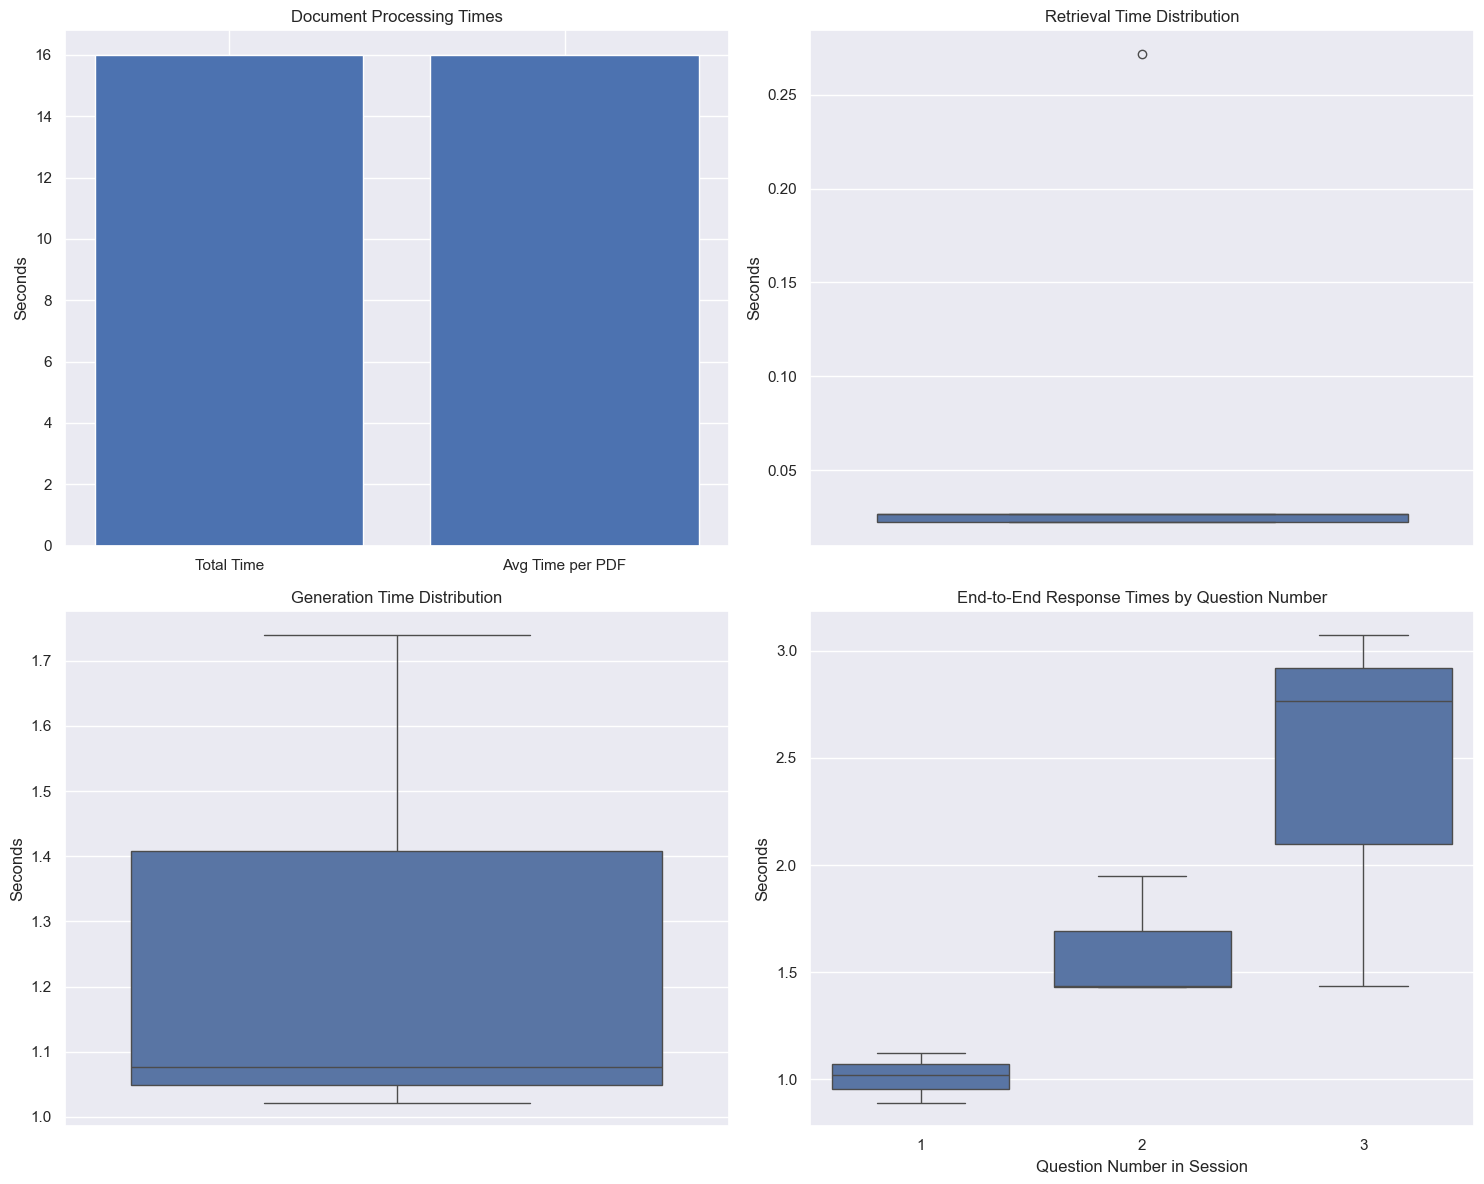

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme()
# plt.style.use('seaborn')

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot results
if not doc_processing_results.empty:
    axes[0, 0].bar(['Total Time', 'Avg Time per PDF'], 
                   [doc_processing_results['total_processing_time'].iloc[0],
                    doc_processing_results['avg_time_per_pdf'].iloc[0]])
    axes[0, 0].set_title('Document Processing Times')
    axes[0, 0].set_ylabel('Seconds')

if not retrieval_results.empty:
    sns.boxplot(data=retrieval_results, y='retrieval_time', ax=axes[0, 1])
    axes[0, 1].set_title('Retrieval Time Distribution')
    axes[0, 1].set_ylabel('Seconds')

if not generation_results.empty:
    sns.boxplot(data=generation_results, y='generation_time', ax=axes[1, 0])
    axes[1, 0].set_title('Generation Time Distribution')
    axes[1, 0].set_ylabel('Seconds')

if not e2e_results.empty:
    sns.boxplot(data=e2e_results, x='question_number', y='total_time', ax=axes[1, 1])
    axes[1, 1].set_title('End-to-End Response Times by Question Number')
    axes[1, 1].set_xlabel('Question Number in Session')
    axes[1, 1].set_ylabel('Seconds')

plt.tight_layout()
plt.show()